# Introduction to FEniCS - Diffusion
In the previous section we were able to assemble the matrix used to solve the Poisson problem using DOLFINx.
In this tutorial we will consider:
 - Derive the variational form of the problem and implement it in FEniCS
 - Build and solve a 2D transient diffusion problem


 In this notebook, we will cover how to implement and sovle a simple diffusion problem using the Finite Element tool [FEniCS](https://fenicsproject.org/). You will learn how to: 

 

# Diffusion equation
 
The diffusion equation is a fundamental equation used to describe many natural processes. It applies well to quantify smooth and "diffuse" transport processes. It is used to describe scalar field such as temperature (transport of heat by thermal conduction, Fourier's law) or concentration (calcium concentration in cells, Fick's law).
Let's assume a scalar field $u_{(t,x)}$, depending on time and space, the diffusion process of $u$ can be approximated by the following partial differential equation: 

$$
\frac{\partial u} {\partial t} - \nabla \cdot \kappa \: \nabla u = S.
$$ 

Equivalent to :

$$
\frac {\partial u} {\partial t} - \nabla \cdot \kappa \: ( \frac {\partial u} {\partial x}, \frac {\partial u} {\partial y}, \frac {\partial u} {\partial z}) = S,
$$ 

where $S$ is a source term. When the diffusion coefficient $\kappa$ is constant in space, the equation can be rearranged as follow:


$$
\frac {\partial u} {\partial t} - \kappa \: (\frac {\partial^2 u} {\partial x^2} + \frac {\partial^2 u} {\partial y^2} + \frac {\partial^2 u} {\partial z^2} ) = S
$$ 




## Solving a 1D steady state diffusion problem 

In this example, we will solve the diffusion equation in its simpliest form assuming a one dimensional problem (along the x-axis) and steady state condition, when the time derivative vanishes to zero $\frac {\partial u} {\partial t} = 0$. 

The equation becomes: 


$$
- \kappa \: \frac {\partial^2 u} {\partial x^2}  = S
$$ 

This simplification leads to the formulation of a Poisson problem as solved step by step in the "introduction to Finite Elements" course.

In order to solve the problem using FEniCS, one has to apply the "FEM recipe" to express the partial differential equation into a variation problem.


### Turning the PDE into a variational problem

As before, we start out by deriving the weak form of our problem. We do this by multiplying by a test function $v$, integrating over the whole domain, and manipulating the integral using integration by parts until no second derivatives occur. 


$$
- \int_\Omega  \Bigl(\kappa \: \frac {\partial^2 u} {\partial x^2}\Bigr) v ~\mathrm{d}x = \int_\Omega  S \: v~\mathrm{d}x
$$ 

Intergration by parts formula:

$$
- \int_\Omega \Bigl(\frac {\partial^2 u} {\partial x^2}\Bigr) v  ~ \mathrm{d}x
= \int_\Omega \: \frac {\partial u} {\partial x} \frac {\partial v} {\partial x} ~\mathrm{d}x
- \int_{\partial \Omega} \frac {\partial u} {\partial x} v ~ \mathrm{d}s
$$ 


Applied to our equation, we obtain:

$$
\int_\Omega  \kappa \: \frac {\partial u} {\partial x} \frac {\partial v} {\partial x} ~\mathrm{d}x - \int_{\partial \Omega} \frac {\partial u} {\partial x} v ~\mathrm{d}s = \int  \limits_\Omega  S \: v ~\mathrm{d}x$$ 

As this has no second derivatives, this is the weak form of our equation.


### FEniCS: First, import the library
Once FEniCS is properly installed, you can start using it in a Python program by importing the dolfinx-module.

In [1]:
# DOLFINx is the user interface of the FEniCS project
from mpi4py import MPI
import dolfinx.fem.petsc
import pyvista

### FEniCS: Discretizing the domain and space of functions
We can now use FEniCS to solve our problem. First, we discretize our domain by creating a mesh within the domain $\Omega$ bounded from 0 to 1. 

In [2]:
mesh = dolfinx.mesh.create_unit_interval(MPI.COMM_WORLD, 20)  # 20 is number of intervals Omega is divided into
grid = pyvista.UnstructuredGrid(*dolfinx.plot.vtk_mesh(mesh))
plotter = pyvista.Plotter()
plotter.add_mesh(grid, color="black", line_width=3)
plotter.add_points(
    grid.points, 
    render_points_as_spheres=True, 
    point_size=15,       # Adjust size as needed
    color="red"
)
plotter.show()

Widget(value='<iframe src="http://localhost:53390/index.html?ui=P_0x316aafe00_0&reconnect=auto" class="pyvista…


Next, choose a space of functions to use for approximating $u$. We use the space of continuous piecewise linear functions on our mesh. Denote this space by $W$.

In [4]:

W = dolfinx.fem.functionspace(mesh, ("Lagrange", 1))

Think of `elem` as a function space of linear functions living on a reference interval. To see how basis functions for these elements look like, see [DefElement: Lagrange](https://defelement.com/elements/lagrange.html#Examples). We construct a {py:class}`FunctionSpace<dolfinx.fem.FunctionSpace>` by calling the creation routine {py:func}`dolfinx.fem.functionspace`, which takes the basis functions living on this interval builds a 'global' function space $W$ by effectively gluing together copies of `elem`. This is not 100% accurate, but a good mental picture.


### FEniCS: Specifying the weak formulation
We need to tell FEniCS the weak formulation of our problem.

In [5]:
import ufl
kappa = dolfinx.fem.Constant(mesh,1.0)

v = ufl.TestFunction(W)  # Symbol representing the test function
u = ufl.TrialFunction(W)  # Symbol representing the unknown

a = kappa * ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx  # left hand side of our equation
S = dolfinx.fem.Constant(mesh,0.0)  # source term
L = S * v * ufl.dx  # right hand side of our equation

Don't be confused! The left hand side (lhs) and the right hand side (rhs) of the equation is often called `a` and `L`, respectively, in the FEniCS demos. To stay consistent with the tutorial book, we will adopt these notations in this notebook. 

### FEniCS: Specifying boundary conditions
There are different types of boundary conditions that we can apply  to the limits of our model. Namely, Dirichlet (or strong), Neumann (or natural), and Robin boundary conditions. For the moment, we will only applied Dirichlet boundary conditions in our model, meaning that we will explicitly set the boundary values in our system of equations, let's say $u(x=0)=0$ and $u(x=1)=2$. More details are given a the end of the notebook to explain the implementation of Dirichlet boundary conditions on the system of equations. 

Note that when Dirichlet boundary conditions are applied, the boundary term in our equation $\int \limits_{\partial \Omega} \frac {\partial u} {\partial x} v~\mathrm{d}s$ can be ignored. This is a nice consequence of the Finite Elements formulation.

In [6]:
import numpy as np
# Dirichlet boundary conditions
value_left = dolfinx.fem.Constant(mesh, 0.0)
value_right = dolfinx.fem.Constant(mesh, 2.0)

dofs_left = dolfinx.fem.locate_dofs_geometrical(W, lambda x: np.isclose(x[0], 0))
bc_left = dolfinx.fem.dirichletbc(value_left, dofs_left, W)

dofs_right = dolfinx.fem.locate_dofs_geometrical(W, lambda x: np.isclose(x[0], 1))
bc_right = dolfinx.fem.dirichletbc(value_right, dofs_right, W)

bcs = [bc_left, bc_right]

To impose the Dirichlet boundary conditon we use the FEniCS object {py:class}`DirichletBC<dolfinx.fem.dirichletbc>` through the constructor {py:func}`dolfinx.fem.dirichletbc`. The first argument is the function space on which we approximate our function, the second argument is the value we want to impose, and the last argument is where the boundary condition should apply.

We are now ready to solve the linear system. We use `uh` to denote the computed solution (as it will dependent on the mesh size `h`).


### FEniCS: Solving


  Residual norms for diffusion_1D solve.
  0 KSP Residual norm 4.004996878900e+01
  1 KSP Residual norm 1.190680938514e-14


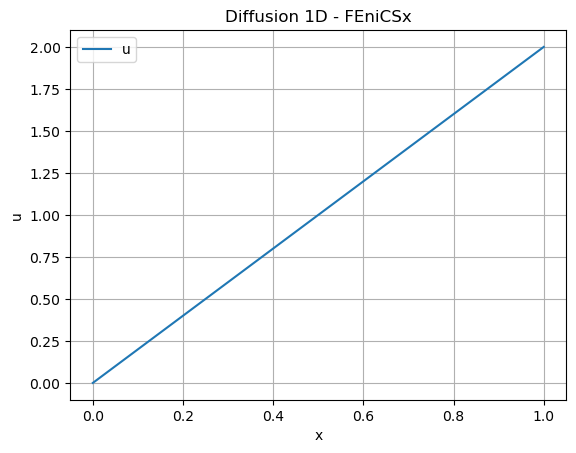

In [7]:
# Solve
problem = dolfinx.fem.petsc.LinearProblem(a, L, bcs=bcs, petsc_options={"ksp_type": "preonly", "pc_type": "lu", "ksp_error_if_not_converged": True,
                                                                        "ksp_monitor": None},
                                                                        petsc_options_prefix="diffusion_1D")
uh = problem.solve()

# Plot - pyvista
from dolfinx import plot
import matplotlib.pyplot as plt
# Create the grid to plot the mesh
topology, cell_types, geometry = plot.vtk_mesh(mesh)
u_grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
# Plot solution on the mesh
u_grid.point_data["u"] = uh.x.array
fig = plt.figure()
u_grid.plot_over_line([0, 0, 0], [1, 0, 0], resolution=100, figure=False, show=False, title="Diffusion 1D - FEniCSx")
plt.xlabel("x")
plt.gca().lines[-1].set_label("u")
plt.gca().legend()
plt.gca().grid(True)
plt.show()

That's it! We have solved a PDE in less than 20 lines of code. That's pretty good value for money. The same procedure can be carried through for more complicated equations as well. Though a bit more code may be required to specify the domains, boundaries and weak forms, the overall structure is still the same:

1. Define the domain
2. Define the {py:class}`dolfinx.fem.FunctionSpace` you want to use for approximating your solution
3. Specify the weak form so FEniCS understands it
4. Specify the boundary conditions
5. Solve the system of linear equations

### Exercise: Solve the transient diffusion problem in 1D

Now that we succefully solved the diffusion equation for steady state conditions, let's look at the time evolution of the solution before equilibrium is reached.

In this case, the equation is: 

$$
\frac {\partial u} {\partial t}  - \: \kappa \: \frac {\partial^2 u} {\partial^2 x}  = \: S
$$ 

One classical approach of evaluating the time derivative term is to approximate it by means of finite differences.The following backward Euler scheme can be used: 

$$
\frac {\partial u} {\partial t} = \frac {u^{new} - u^{old}}{dt}
$$ 

As before, we express the variational form of our problem with the approximated time derivation term: 

$$
\int \limits_{\Omega}  \Bigl(\frac {u - u^{old}}{dt}\Bigr) \: v \: \text{dx}  + \int  \limits_{\Omega} \: \kappa \: \frac {\partial u} {\partial x} \frac {\partial v} {\partial x} \: \text{dx} = \int  \limits_{\Omega} S \: v \: \text{dx} + \: \int \limits_{\partial \Omega} \frac {\partial u} {\partial x} v \: \text{ds}
$$ 

One can rearrange the equation in a way that all the unknown terms are present in the left hand side and all the known terms present in the right hand side. 

$$
\int \limits_{\Omega}  \frac {1}{dt} u \: v \: \text{dx}  + \int  \limits_{\Omega} \: \kappa \: \frac {\partial u} {\partial x} \frac {\partial v} {\partial x} \: \text{dx} = \int \limits_{\Omega}  \frac {1}{dt} u^{old} \: v \: \text{dx}  + \int  \limits_{\Omega} S \: v \: \text{dx}  + \: \int \limits_{\partial \Omega} \frac {\partial u} {\partial x} v \: \text{ds}
$$ 


### Hints



We first need to discretize our domain into a FE mesh.
Add your code below:

In [8]:
# Add code here

In this code you need to introduce some new variables
- `dt`, the time step, which is a {py:class}`dolfinx.fem.Constant` object that appear in both the righ hand side (`a`) and left hand side (`L`) form. 
- `nb_t`, that we will use to constrain the maximum number of time steps to run.
- `u_old` a {py:class}`dolfinx.fem.Function` that should hold the solution at the previous time step. **NOTE**: A {py:class}`Function<dolfinx.fem.Function>` variable is initialized with zeros when created in Python.

#### FEniCS: Time loop

Since we want to look at the time evolution of the diffusion process, we need to solve the problem step by step within a **time loop** and update the solution over the time step `dt`.

In [ ]:
# Uncomment and modify this code
# for t in range(nb_t):
#     #
#     # Write the necessary code lines to solve the system of equations!
#     #
#     # update the old solution to the new one for next time step
#.    uh_old.interpolate(uh)

**NOTE:** When defining the function `u_old` in the variational form, FEniCS will automatically take into account the updated values in the system of equations when we execute {py:meth}`u_old.interpolate(uh)<dolfinx.fem.Function.interpolate>`.   
    

The solution can be found {ref}`here<sol-l12-diffusion-transient>`.

## Solving a transient 2D diffusion problem 


$$
\frac {\partial u} {\partial t}  - \: \kappa \: \Bigl(\frac {\partial^2 u} {\partial^2 x} +  \frac {\partial^2 u} {\partial^2 y}\Bigr)  = \: S
$$ 


## Turning the PDE into a variational problem

$$
\int \limits_{\Omega} \Bigl(\frac {u - u^{old}}{dt}\Bigr) \: v \: \text{dx}  + \int  \limits_{\Omega} \: \kappa \:  \Bigl(\frac {\partial u} {\partial x} \frac {\partial v} {\partial x} + \frac {\partial u} {\partial y} \frac {\partial v} {\partial y}\Bigr) \: \text{dx} = \int  \limits_{\Omega} S \: v \: \text{dx}  + \: \int \limits_{\partial \Omega} \frac {\partial u} {\partial x} v \: \text{ds} + \: \int \limits_{\partial \Omega} \frac {\partial u} {\partial y} v \: \text{ds}
$$ 


Once we rearrange the unknown terms in the left hand side and the known terms in the right hand side, we obtain:

$$
\int \limits_{\Omega}  \frac {1}{dt} u \: v \: \text{dx}  + \int  \limits_{\Omega} \: \kappa \: \Bigl( \frac {\partial u} {\partial x}  \frac {\partial v} {\partial x} + \frac {\partial u} {\partial y} \frac {\partial v} {\partial y}\Bigr) \: \text{dx} = \int \limits_{\Omega}  \frac {1}{dt} u^{old} \: v \: \text{dx}  + \int  \limits_{\Omega} S \: v \: \text{dx}  + \: \int \limits_{\partial \Omega} \frac {\partial u} {\partial x} v \: \text{ds} + \: \int \limits_{\partial \Omega} \frac {\partial u} {\partial y} v \: \text{ds}
$$ 



# Exercise 2: Solve a 2D transient diffusion problem

In [ ]:
# Add code solving the 2D transient diffusion problem here

## Extra material
How are Dirichlet boundary conditions enforced?
See: [FEniCS workshop notes](https://jsdokken.com/FEniCS-workshop/src/form_compilation/alternate_form.html#lifting)
for a detailed description of how this is enforced and a sneak-peak on how to handle non-linear PDEs!